### Random Forest

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Importing the dataset
X = pd.read_csv('D:/sgk62/Documents/Master of AI/AML/Assignment Data/X_preprocessed_10K_RemovedMorefeature_1.csv')
y = pd.read_csv('D:/sgk62/Documents/Master of AI/AML/Assignment Data/y_preprocessed_10K_RemovedMorefeature_1.csv')

In [3]:
y

,IncidentGrade
0,1
1,1
2,0
3,0
4,2
...,...
20905,2
20906,2
20907,2
20908,2


In [4]:
# Check type
if isinstance(y, pd.Series):
    print("y is a Series")
elif isinstance(y, pd.DataFrame):
    print("y is a DataFrame")
else:
    print("y is neither a Series nor a DataFrame")

y is a DataFrame


In [5]:
# Convert the DataFrame to a Series
y= y.squeeze()

In [6]:
# Check type again to ensure it is converted to series type
if isinstance(y, pd.Series):
    print("y is a Series")
elif isinstance(y, pd.DataFrame):
    print("y is a DataFrame")
else:
    print("y is neither a Series nor a DataFrame")

y is a Series


In [7]:
X

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,ActionGrouped,...,Url,DeviceName,NetworkMessageId,EmailClusterId,RegistryValueName,ApplicationName,ThreatFamily,LastVerdict,CountryCode,City
0,0.206030,0.049739,0.000769,0.003736,0.586498,0.000118,0.000009,0.5625,0.889362,0.0,...,0.405365,1.0,1.0,0.213793,1.0,1.0,0.232877,0.0,1.000000,1.000000
1,0.261307,0.001855,0.720970,0.481895,0.885177,0.000473,0.000027,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,0.033058,0.000282
2,0.422111,0.022930,0.226757,0.719937,0.894199,0.000000,0.000000,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
3,0.422111,0.022930,0.226757,0.719937,0.894199,0.000000,0.000000,0.5625,0.340426,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
4,0.477387,0.000000,0.000334,0.097514,0.718445,0.000000,0.000000,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20905,0.407035,0.016186,0.001463,0.025169,0.655717,0.000000,0.000000,0.5625,0.659574,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,0.0,1.000000,1.000000
20906,0.753769,0.009442,0.042898,0.659267,0.755525,0.000000,0.000000,0.5625,0.336170,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
20907,0.100503,0.014163,0.000574,0.646035,0.633835,0.010772,0.000698,0.5625,0.693617,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000
20908,0.889447,0.000000,0.000162,0.761881,0.779848,0.000355,0.000018,0.5625,0.327660,0.0,...,1.000000,1.0,1.0,0.213793,1.0,1.0,0.232877,1.0,1.000000,1.000000


In [8]:
X.describe()

,Id,OrgId,IncidentId,AlertId,Timestamp,DetectorId,AlertTitle,Category,MitreTechniques,ActionGrouped,...,Url,DeviceName,NetworkMessageId,EmailClusterId,RegistryValueName,ApplicationName,ThreatFamily,LastVerdict,CountryCode,City
count,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,...,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000,20910.000000
mean,0.497559,0.033884,0.115710,0.252808,0.706706,0.014109,0.022140,0.476417,0.414072,0.000909,...,0.946750,0.926758,0.932055,0.216217,0.998493,0.981920,0.234360,0.951028,0.908210,0.916833
std,0.290797,0.070170,0.201824,0.269392,0.156097,0.050086,0.094446,0.221131,0.201055,0.030131,...,0.212948,0.244203,0.230001,0.036493,0.038501,0.129177,0.029474,0.193497,0.280374,0.270123
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.246231,0.001686,0.000682,0.015462,0.623172,0.000118,0.000009,0.375000,0.327660,0.000000,...,1.000000,1.000000,1.000000,0.213793,1.000000,1.000000,0.232877,1.000000,1.000000,1.000000
50%,0.492462,0.008093,0.013556,0.145919,0.708411,0.001302,0.000107,0.562500,0.327660,0.000000,...,1.000000,1.000000,1.000000,0.213793,1.000000,1.000000,0.232877,1.000000,1.000000,1.000000
75%,0.753769,0.033721,0.133192,0.463239,0.830790,0.006747,0.001253,0.562500,0.387234,0.000000,...,1.000000,1.000000,1.000000,0.213793,1.000000,1.000000,0.232877,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [9]:
X = X.drop(columns=['Id'])

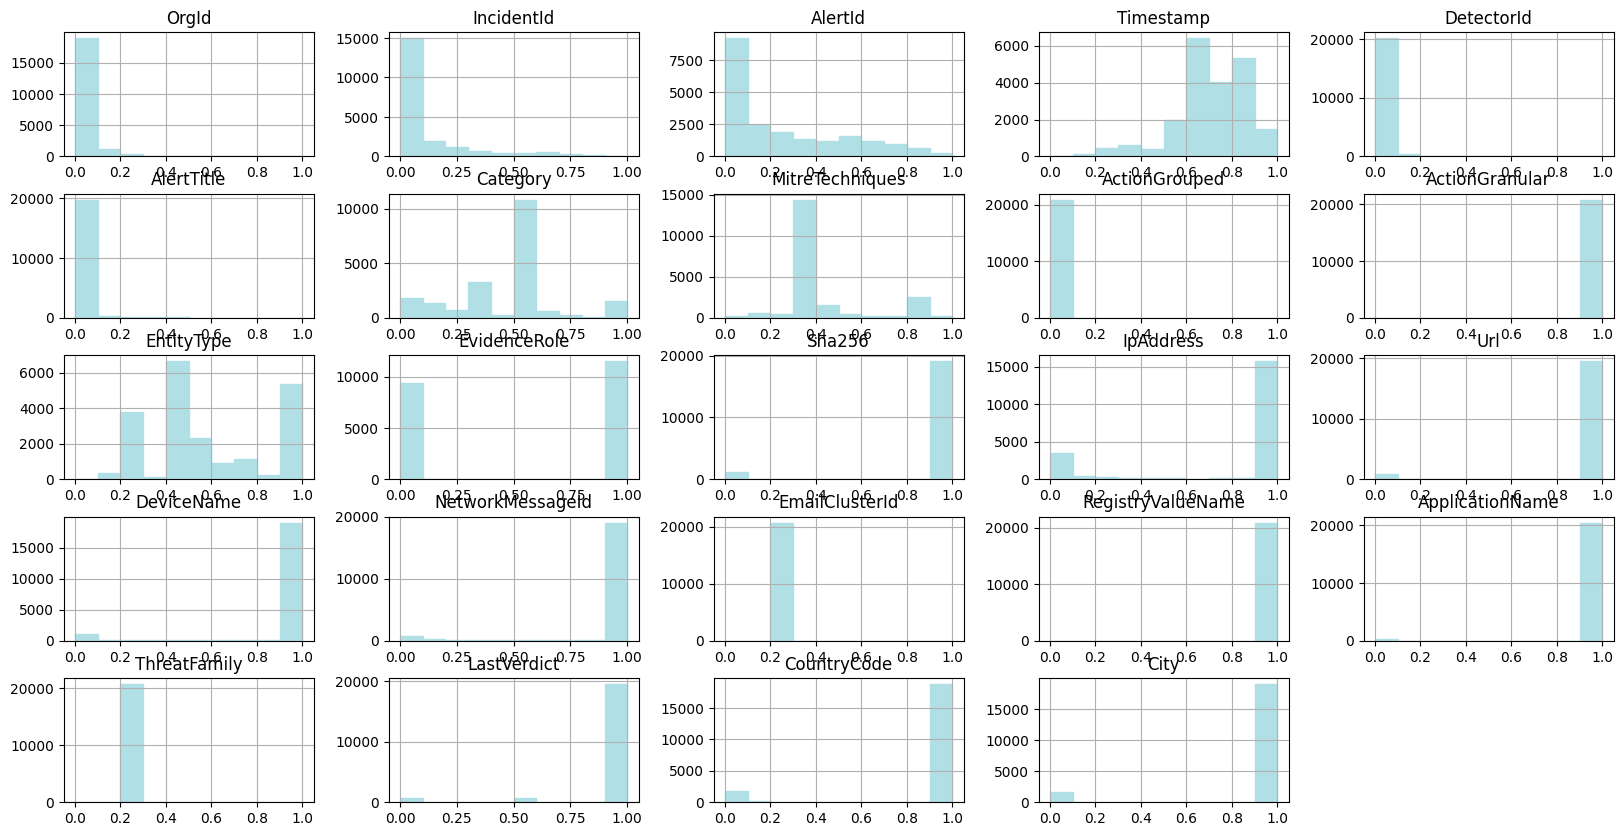

In [10]:
import matplotlib.pyplot as plt
X.hist(figsize=(20,10), edgecolor="powderblue", color="powderblue")
plt.show()

In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 1)

In [21]:
print(y_train.value_counts())

IncidentGrade
1    5617
0    5576
2    5535
Name: count, dtype: int64


In [22]:
print(y_test.value_counts())

IncidentGrade
2    1435
0    1394
1    1353
Name: count, dtype: int64


Basic Random Forest

In [12]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
print(rf.get_params())

{'bootstrap': True, 'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': None, 'oob_score': False, 'random_state': None, 'verbose': 0, 'warm_start': False}


In [13]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

# Fit the model on training data
rf.fit(X_train, y_train)

# Predict on training data
y_train_pred = rf.predict(X_train)

# Calculate metrics on training data
rf_acc_train = accuracy_score(y_train, y_train_pred) * 100
rf_pre_train = precision_score(y_train, y_train_pred, average='micro')
rf_recall_train = recall_score(y_train, y_train_pred, average='micro')
rf_f1_train = f1_score(y_train, y_train_pred, average='micro')

print("Training Data Metrics:")
print("RF - Accuracy: {:.3f}".format(rf_acc_train))
print("RF - Precision: {:.3f}".format(rf_pre_train))
print("RF - Recall: {:.3f}".format(rf_recall_train))
print("RF - F1_Score: {:.3f}".format(rf_f1_train))


Training Data Metrics:
RF - Accuracy: 100.000
RF - Precision: 1.000
RF - Recall: 1.000
RF - F1_Score: 1.000


In [14]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

# Predict on test data
y_pred = rf.predict(X_test)

# Get the accuracy score
rf_acc = accuracy_score(y_test, y_pred)*100
rf_pre = precision_score(y_test, y_pred, average='micro')
rf_recall = recall_score(y_test, y_pred, average='micro')
rf_f1_ = f1_score(y_test, y_pred, average='micro')

print("\nTest Data Metrics:")
print("\nRF - Accuracy: {:.3f}.".format(rf_acc))
print("RF - Precision: {:.3f}.".format(rf_pre))
print("RF - Recall: {:.3f}.".format(rf_recall))
print("RF - F1_Score: {:.3f}.".format(rf_f1_))
print ('\n Clasification Report:\n', classification_report(y_test,y_pred))


Test Data Metrics:

RF - Accuracy: 89.479.
RF - Precision: 0.895.
RF - Recall: 0.895.
RF - F1_Score: 0.895.

 Clasification Report:
               precision    recall  f1-score   support

           0       0.83      0.93      0.88      1394
           1       0.93      0.90      0.91      1353
           2       0.94      0.86      0.90      1435

    accuracy                           0.89      4182
   macro avg       0.90      0.90      0.90      4182
weighted avg       0.90      0.89      0.90      4182



In [15]:
df = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.round(2)})
print(df.head())

       Actual  Predicted
5607        2          2
5825        0          0
14764       2          2
4570        2          0
17630       1          1


Random Forest with Hyper-Parameter Tuning

In [16]:
from numpy import arange
# The function to measure the quality of a split
criterion = ['gini', 'entropy']

# Class Weight
class_weight = ['balanced', 'balanced_subsample'] # {“balanced”, “balanced_subsample”}, dict or list of dicts, default=None. balanced_subsample replace dict
             
# Number of trees in random forest
n_estimators = arange(200, 1000, 100)

# Number of features to consider at every split
max_features = ['log2', 'sqrt'] #Changed in version 1.1: The default of max_features changed from "auto" to "sqrt".

# Maximum number of levels in tree
max_depth = arange(10, 110, 10)

# Minimum number of samples required to split a node
min_samples_split = [2, 5, 10]

# Minimum number of samples required at each leaf node
min_samples_leaf = [1, 2, 4]

# Method of selecting samples for training each tree
bootstrap = [True, False]

# Create the random grid
parameters = {'criterion': criterion,
               'class_weight': class_weight,
               'n_estimators': n_estimators,
               'max_features': max_features,
               'max_depth': max_depth,
               'min_samples_split': min_samples_split,
               'min_samples_leaf': min_samples_leaf,
               'bootstrap': bootstrap}

print(parameters)

{'criterion': ['gini', 'entropy'], 'class_weight': ['balanced', 'balanced_subsample'], 'n_estimators': array([200, 300, 400, 500, 600, 700, 800, 900]), 'max_features': ['log2', 'sqrt'], 'max_depth': array([ 10,  20,  30,  40,  50,  60,  70,  80,  90, 100]), 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 2, 4], 'bootstrap': [True, False]}


Random Forest - Random Search Cross Validation

In [17]:
from sklearn.model_selection import RandomizedSearchCV

rf_random = RandomizedSearchCV(estimator = rf, param_distributions = parameters, n_iter = 100, cv = 5, verbose=2, random_state=1, n_jobs = -1)
# Fit the random search model
rf_random.fit(X_train, y_train)

print("\nBest Parameters: ", rf_random.best_params_)
print("Best Scores: ", rf_random.best_score_) 


from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

y_pred = rf_random.predict(X_test)

# Get the accuracy score
rf_acc = accuracy_score(y_test, y_pred)*100
rf_pre = precision_score(y_test, y_pred, average='micro')
rf_recall = recall_score(y_test, y_pred, average='micro')
rf_f1_ = f1_score(y_test, y_pred, average='micro')

print("\nRF - Accuracy: {:.3f}.".format(rf_acc))
print("RF - Precision: {:.3f}.".format(rf_pre))
print("RF - Recall: {:.3f}.".format(rf_recall))
print("RF - F1_Score: {:.3f}.".format(rf_f1_))
print ('\n Clasification Report:\n', classification_report(y_test,y_pred))
print()

df1 = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred.round(2)})
print(df1.head())

Fitting 5 folds for each of 100 candidates, totalling 500 fits

Best Parameters:  {'n_estimators': np.int64(500), 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': np.int64(80), 'criterion': 'gini', 'class_weight': 'balanced', 'bootstrap': False}
Best Scores:  0.9002267973628463

RF - Accuracy: 90.435.
RF - Precision: 0.904.
RF - Recall: 0.904.
RF - F1_Score: 0.904.

 Clasification Report:
               precision    recall  f1-score   support

           0       0.85      0.93      0.89      1394
           1       0.93      0.91      0.92      1353
           2       0.94      0.88      0.91      1435

    accuracy                           0.90      4182
   macro avg       0.91      0.90      0.90      4182
weighted avg       0.91      0.90      0.90      4182


       Actual  Predicted
5607        2          2
5825        0          0
14764       2          2
4570        2          0
17630       1          1


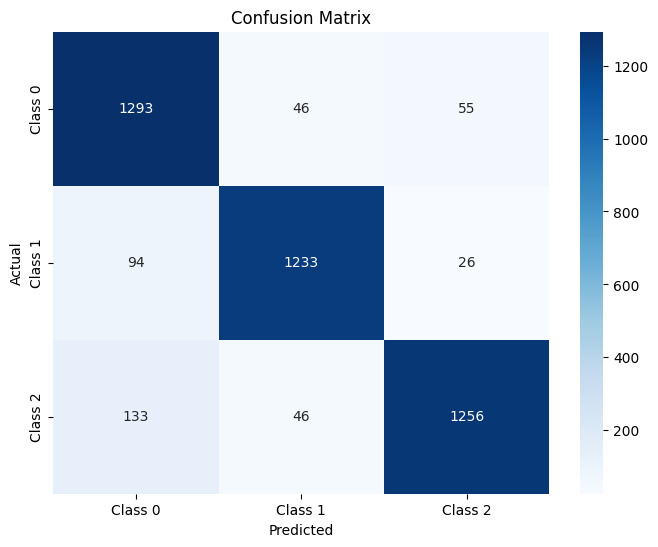

In [18]:
import seaborn as sns
# Generate and plot the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['Class 0', 'Class 1', 'Class 2'], yticklabels=['Class 0', 'Class 1', 'Class 2'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


**Grid Search** - unable to perform due to laptop is unable to support